<a href="https://colab.research.google.com/github/Perlangas28/Simulacion_1/blob/main/TIBASA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación del peso de tinas (TIBASA)
**Alumna: Perla Blancas Hernández**  
**Materia:** Simulación 1

**Resolver por simulación a detalle, en una notebook utilizando la metodología propuesta en el curso.**

**La empresa TIBASA (Fabricante de tinas de baño) tiene asignado un camión especial para el transporte de tinas terminadas. Dicho camión transporta diariamente 5 tinas. El peso de cada tina sigue la distribución triangular de la imagen anexa.
Si la capacidad del camión es de 1 tonelada, ¿cuál es la probabilidad de que el peso de las tinas exceda la capacidad del camión?**
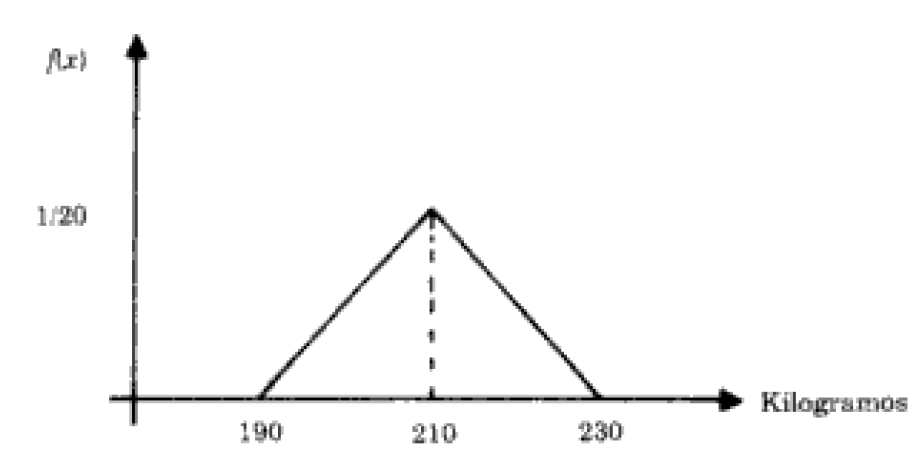

**Solución**

En este problema se analiza la probabilidad de que un camión que transporta 5 tinas exceda su capacidad de 1000 kg.

Cada tina tiene un peso que sigue una distribución triangular con parámetros:
- a = 190
- c = 210 (moda)
- b = 230

Se resolverá el problema mediante simulación usando el método de la transformada inversa.

In [10]:
import random as r
import numpy as np
import matplotlib.pyplot as plt

Se utiliza la transformada inversa para generar variables con distribución triangular.

In [11]:
def triangular(a, c, b, n):
  l = []
  for i in range(n):
    u = r.random()
    F_c = (c - a) / (b - a)

    if u < F_c:
      x = a + np.sqrt(u * (b - a) * (c - a))
    else:
      x = b - np.sqrt((1 - u) * (b - a) * (b - c))

    l.append(x)

  return l

Se generan 10,000 datos para verificar que la distribución tenga forma triangular.

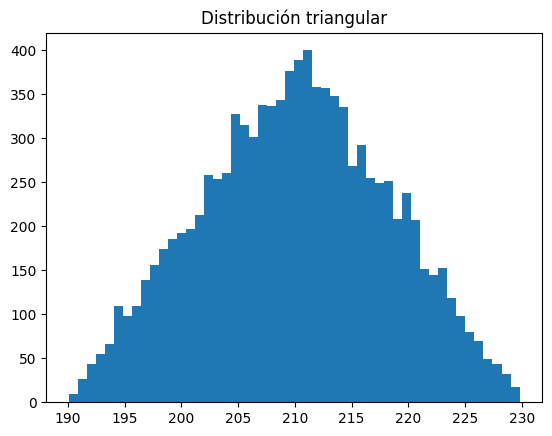

In [12]:
M = triangular(190, 210, 230, 10000)
plt.hist(M, bins=50)
plt.title("Distribución triangular")
plt.show()

La media teórica de una distribución triangular es:

E[X] = (a + b + c) / 3

Se compara con la media simulada.

In [13]:
media = np.mean(M)
print("Media aproximada:", media)

Media aproximada: 210.04254398146253


Se simula el peso total de 5 tinas y se evalúa si excede los 1000 kg.

Se repite el experimento muchas veces para estimar la probabilidad.

In [14]:
def simulacion_camion(N):
  excede = 0
  sumas = []

  for i in range(N):
    tinas = triangular(190, 210, 230, 5)
    S = sum(tinas)
    sumas.append(S)

    if S > 1000:
      excede += 1

  prob = excede / N
  return prob, sumas

Se ejecuta la simulación con un número grande de repeticiones para obtener una estimación precisa.

In [15]:
prob, sumas = simulacion_camion(100000)

print("Probabilidad de exceder 1000 kg:", prob)

Probabilidad de exceder 1000 kg: 0.9976


Se grafica la distribución del peso total de las 5 tinas.

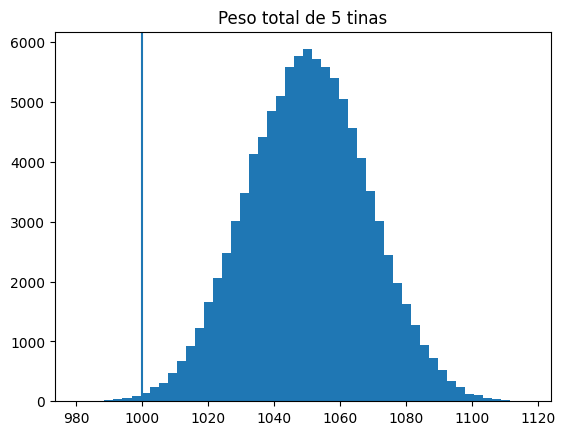

In [16]:
plt.hist(sumas, bins=50)
plt.axvline(1000)
plt.title("Peso total de 5 tinas")
plt.show()